## 1. Regridding ERA5 onto the ORAS5 grid

This notebook follows on from the previous regridding notebook, but instead regrids ERA5 onto ORAS5.

I only keep ORAS5 cells that lie inside the ERA5 domain:
- longitude: -80 to 2
- latitude: 0 to 90

I then apply the native ORAS5 ocean mask so that only ocean points are compared.

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.interpolate import griddata

In [4]:
# ORAS5 monthly files
file_paths = [
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202201_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202202_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202203_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202204_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202205_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202206_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202207_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202208_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202209_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202210_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202211_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202212_OPER_v0.1.nc",
]

oras5_ds = xr.open_mfdataset(file_paths, combine="nested", concat_dim="time_counter")

oras5_sst = oras5_ds["sosstsst"]
nav_lat = oras5_ds["nav_lat"]
nav_lon = oras5_ds["nav_lon"]

oras5_sst_annual = oras5_sst.mean("time_counter", skipna=True)

In [37]:
# ERA5 file
file_path_era5 = r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\data_stream-moda_stepType-avgua.nc"

era5_ds = xr.open_dataset(file_path_era5)

era5_sst = era5_ds["sst"] - 273.15
era5_sst_annual = era5_sst.sel(valid_time="2022").mean("valid_time")

lat_era5 = era5_ds["latitude"].values
lon_era5 = era5_ds["longitude"].values
lon2_era5, lat2_era5 = np.meshgrid(lon_era5, lat_era5)

In [6]:
# Flatten ERA5 source grid
src_lon = lon2_era5.ravel()
src_lat = lat2_era5.ravel()
src_val = era5_sst_annual.values.ravel()

valid_src = np.isfinite(src_lon) & np.isfinite(src_lat) & np.isfinite(src_val)
points = np.column_stack([src_lon[valid_src], src_lat[valid_src]])
values = src_val[valid_src]

# ERA5 coverage mask on the ORAS5 grid
in_era5_domain = (
    (nav_lon >= lon_era5.min()) & (nav_lon <= lon_era5.max()) &
    (nav_lat >= lat_era5.min()) & (nav_lat <= lat_era5.max())
)

# Native ORAS5 ocean mask
oras5_ocean_mask = np.isfinite(oras5_sst_annual)

# Final valid comparison mask = ocean points that also lie inside ERA5 domain
comparison_mask = oras5_ocean_mask & in_era5_domain

In [7]:
# Interpolate ERA5 annual mean onto ORAS5 grid
era5_linear = griddata(
    points,
    values,
    (nav_lon.values, nav_lat.values),
    method="linear"
)

era5_nearest = griddata(
    points,
    values,
    (nav_lon.values, nav_lat.values),
    method="nearest"
)

# Fill only interpolation gaps, then mask back to valid comparison area
era5_on_oras5 = np.where(np.isfinite(era5_linear), era5_linear, era5_nearest)
era5_on_oras5 = np.where(comparison_mask, era5_on_oras5, np.nan)

In [38]:
era5_on_oras5_da = xr.DataArray(
    era5_on_oras5,
    dims=("y", "x"),
    coords={
        "y": oras5_ds["y"],
        "x": oras5_ds["x"],
        "nav_lat": (("y", "x"), nav_lat.values),
        "nav_lon": (("y", "x"), nav_lon.values),
    },
    name="era5_regridded_to_oras5"
)

oras5_sst_annual_masked = oras5_sst_annual.where(comparison_mask)
era5_on_oras5_masked = era5_on_oras5_da.where(comparison_mask)

## 2. North Atlantic comparison

Now compare the regridded ERA5 field with the native ORAS5 annual mean over the North Atlantic only.

In [39]:
ATL = dict(lon_min=-80, lon_max=2, lat_min=0, lat_max=85)

era_atl = era5_on_oras5_masked.where(
    (era5_on_oras5_masked["nav_lon"] >= ATL["lon_min"]) &
    (era5_on_oras5_masked["nav_lon"] <= ATL["lon_max"]) &
    (era5_on_oras5_masked["nav_lat"] >= ATL["lat_min"]) &
    (era5_on_oras5_masked["nav_lat"] <= ATL["lat_max"])
)

oras_atl = oras5_sst_annual_masked.where(
    (oras5_sst_annual_masked["nav_lon"] >= ATL["lon_min"]) &
    (oras5_sst_annual_masked["nav_lon"] <= ATL["lon_max"]) &
    (oras5_sst_annual_masked["nav_lat"] >= ATL["lat_min"]) &
    (oras5_sst_annual_masked["nav_lat"] <= ATL["lat_max"])
)

vmin = float(np.nanmin([era_atl.values, oras_atl.values]))
vmax = float(np.nanmax([era_atl.values, oras_atl.values]))

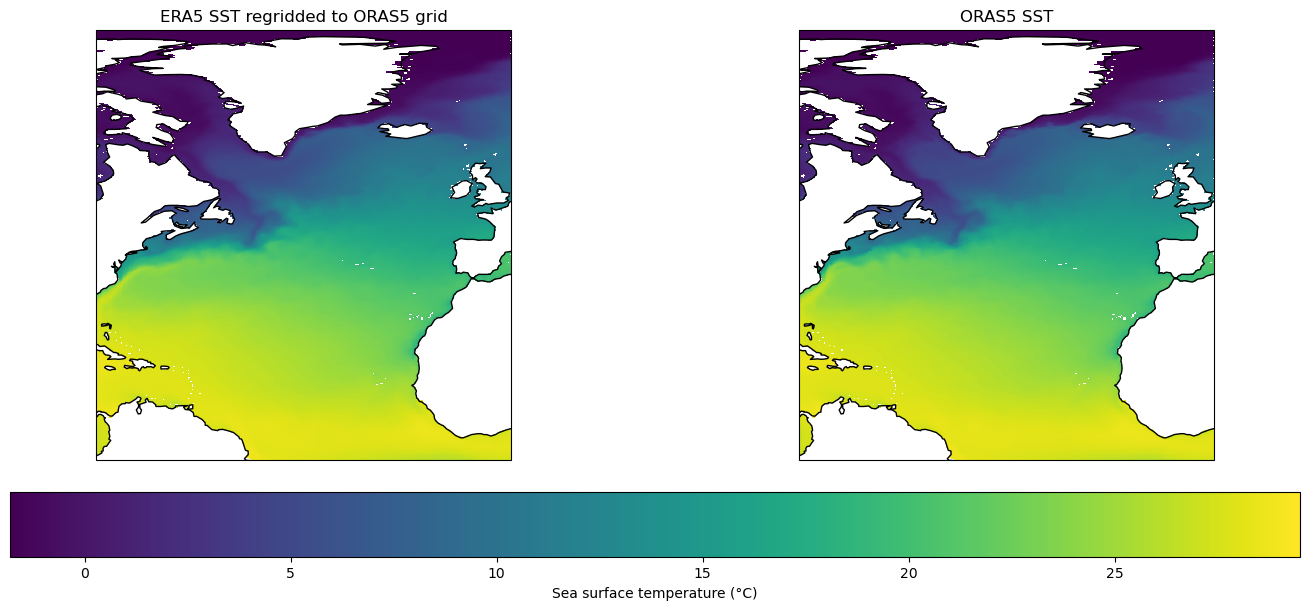

In [40]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

for ax, field, title in [
    (axes[0], era_atl, "ERA5 SST regridded to ORAS5 grid"),
    (axes[1], oras_atl, "ORAS5 SST"),
]:
    ax.set_extent([ATL["lon_min"], ATL["lon_max"], ATL["lat_min"], ATL["lat_max"]],
                  crs=ccrs.PlateCarree())
    ax.coastlines()
    pm = ax.pcolormesh(
        field["nav_lon"], field["nav_lat"], field.values,
        shading="auto",
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title)

cbar = fig.colorbar(pm, ax=axes, orientation="horizontal", pad=0.06)
cbar.set_label("Sea surface temperature (°C)")
plt.show()

## 3. UK zooms

In [19]:
proj = ccrs.PlateCarree()

def make_box(field, box):
    return field.where(
        (field["nav_lon"] >= box["lon_min"]) & (field["nav_lon"] <= box["lon_max"]) &
        (field["nav_lat"] >= box["lat_min"]) & (field["nav_lat"] <= box["lat_max"])
    )

def plot_pair(box, title_left="ERA5 regridded", title_right="ORAS5 native"):
    era_box = make_box(era5_on_oras5_masked, box)
    oras_box = make_box(oras5_sst_annual_masked, box)

    vmin = float(np.nanmin([era_box.values, oras_box.values]))
    vmax = float(np.nanmax([era_box.values, oras_box.values]))

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 5),
        subplot_kw={"projection": proj},
        constrained_layout=True
    )

    for ax, field, title in [
        (axes[0], era_box, title_left),
        (axes[1], oras_box, title_right),
    ]:
        ax.set_extent([box["lon_min"], box["lon_max"], box["lat_min"], box["lat_max"]],
                      crs=proj)
        ax.coastlines()
        pm = ax.pcolormesh(
            field["nav_lon"], field["nav_lat"], field.values,
            shading="auto",
            transform=proj,
            cmap="viridis",
            vmin=vmin, vmax=vmax
        )
        ax.set_title(title)

    cbar = fig.colorbar(pm, ax=axes, orientation="horizontal", pad=0.08)
    cbar.set_label("SST (°C)")
    plt.show()

    return era_box, oras_box

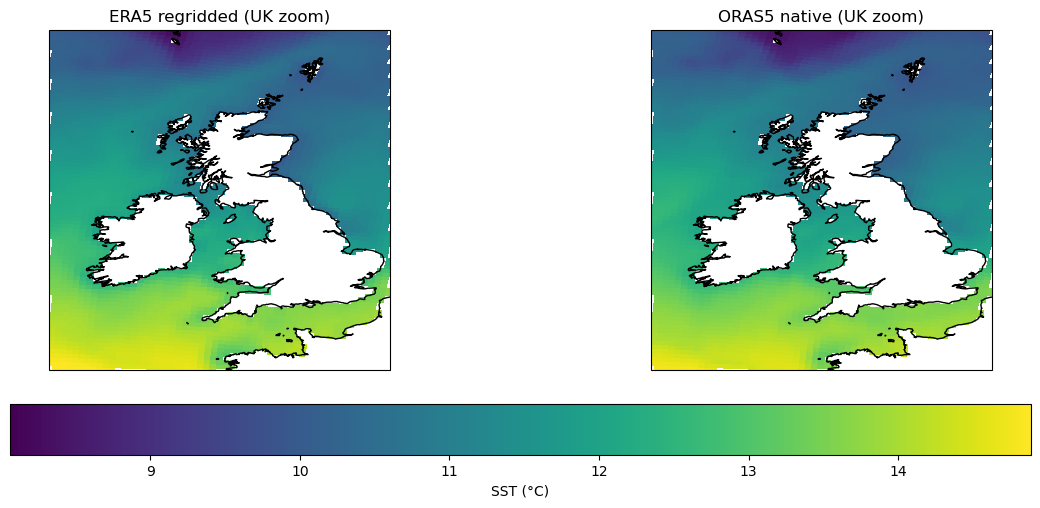

In [20]:
UK = dict(lon_min=-12, lon_max=2, lat_min=48, lat_max=62)
era_uk1, oras_uk1 = plot_pair(UK, "ERA5 regridded (UK zoom)", "ORAS5 native (UK zoom)")

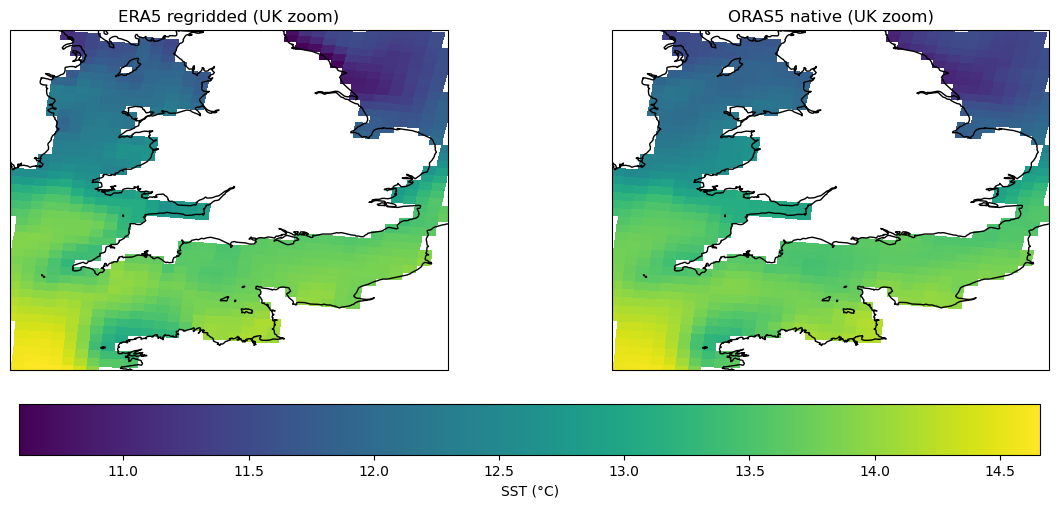

In [21]:
UK = dict(lon_min=-7, lon_max=2, lat_min=48, lat_max=55)
era_uk2, oras_uk2 = plot_pair(UK, "ERA5 regridded (UK zoom)", "ORAS5 native (UK zoom)")

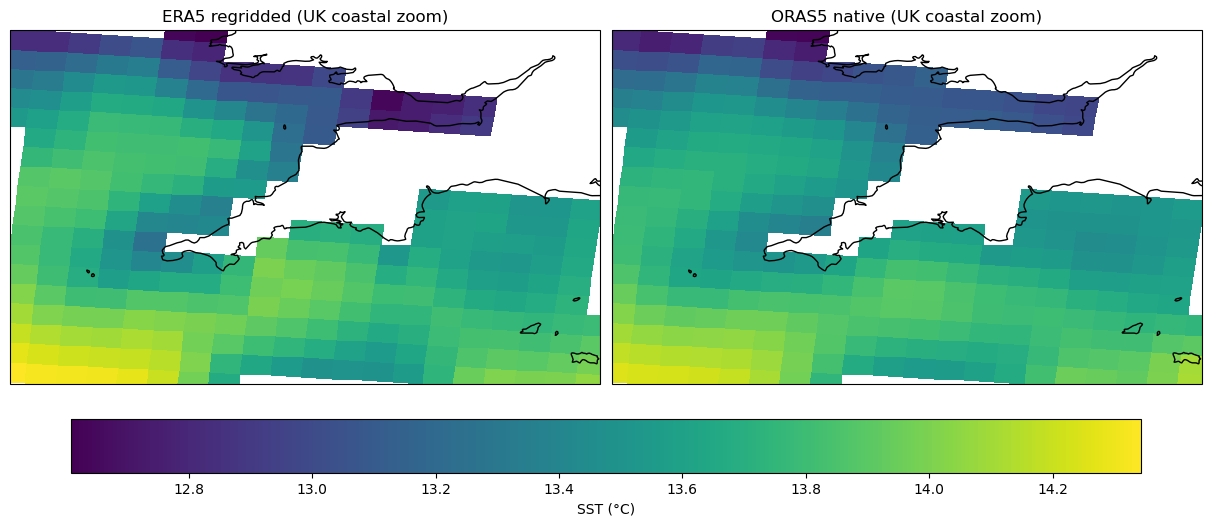

In [22]:
UK = dict(lon_min=-7, lon_max=-2, lat_min=49, lat_max=52)
era_uk3, oras_uk3 = plot_pair(UK, "ERA5 regridded (UK coastal zoom)", "ORAS5 native (UK coastal zoom)")

## 4. Box-mean comparison

In [24]:
era_mean = float(era_uk3.mean().values)
oras_mean = float(oras_uk3.mean().values)

abs_diff_box = era_mean - oras_mean
rel_diff_box = abs_diff_box / oras_mean

print("UK coastal box mean SST:")
print(f" ERA5 (regridded): {era_mean:.3f} °C")
print(f" ORAS5          : {oras_mean:.3f} °C")
print()
print("Difference:")
print(f" Absolute (ERA5 − ORAS5): {abs_diff_box:.3f} °C")
print(f" Relative             : {rel_diff_box*100:.2f} %")

UK coastal box mean SST:
 ERA5 (regridded): 13.640 °C
 ORAS5          : 13.605 °C

Difference:
 Absolute (ERA5 − ORAS5): 0.035 °C
 Relative             : 0.26 %


In [25]:
era_mean = float(era_atl.mean().values)
oras_mean = float(oras_atl.mean().values)

abs_diff_box = era_mean - oras_mean
rel_diff_box = abs_diff_box / oras_mean

print("Atlantic box mean SST:")
print(f" ERA5 (regridded): {era_mean:.3f} °C")
print(f" ORAS5          : {oras_mean:.3f} °C")
print()
print("Difference:")
print(f" Absolute (ERA5 − ORAS5): {abs_diff_box:.3f} °C")
print(f" Relative             : {rel_diff_box*100:.2f} %")

Atlantic box mean SST:
 ERA5 (regridded): 15.347 °C
 ORAS5          : 15.343 °C

Difference:
 Absolute (ERA5 − ORAS5): 0.004 °C
 Relative             : 0.02 %


## 5. Difference distributions

(Only NA only)

In [27]:
era, oras = xr.align(era_atl, oras_atl, join="exact")
mask = np.isfinite(era) & np.isfinite(oras)

signed_diff = (era - oras).where(mask)
abs_diff = np.abs(signed_diff)

eps = 1e-12
rel = (abs_diff / (np.abs(oras) + eps)).where(mask)

In [28]:
signed_vals = signed_diff.values.ravel()
signed_vals = signed_vals[np.isfinite(signed_vals)]

abs_vals = abs_diff.values.ravel()
abs_vals = abs_vals[np.isfinite(abs_vals)]

rel_vals = rel.values.ravel()
rel_vals = rel_vals[np.isfinite(rel_vals)]

print(f"Cells compared: N = {rel_vals.size}")
print(f"Mean bias (ERA5 − ORAS5): {signed_vals.mean():.3f} °C")
print(f"RMS difference         : {np.sqrt((signed_vals**2).mean()):.3f} °C")
print(f"Mean absolute diff     : {abs_vals.mean():.3f} °C")
print(f"RMS absolute diff      : {np.sqrt((abs_vals**2).mean()):.3f} °C")
print(f"Mean relative abs diff : {rel_vals.mean():.4f}")
print(f"RMS relative abs diff  : {np.sqrt((rel_vals**2).mean()):.4f}")

Cells compared: N = 95605
Mean bias (ERA5 − ORAS5): 0.004 °C
RMS difference         : 0.304 °C
Mean absolute diff     : 0.143 °C
RMS absolute diff      : 0.304 °C
Mean relative abs diff : 0.1332
RMS relative abs diff  : 10.8292


### Signed difference map

C:\Users\itsna\AppData\Local\Temp\ipykernel_25432\2581785270.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(


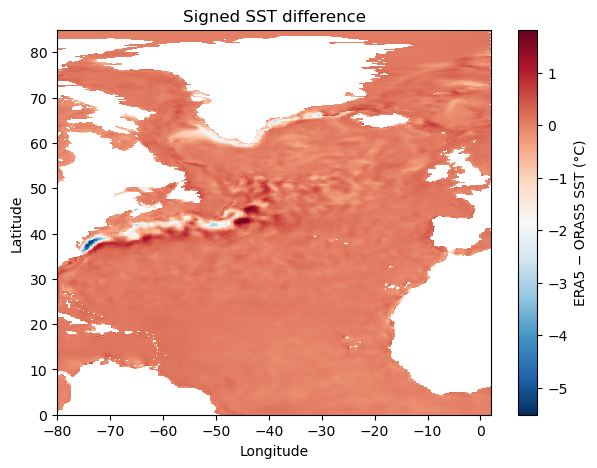

In [30]:
plt.figure(figsize=(7, 5))
plt.pcolormesh(
    signed_diff["nav_lon"],
    signed_diff["nav_lat"],
    signed_diff,
    shading="auto",
    cmap="RdBu_r"
)
plt.colorbar(label="ERA5 − ORAS5 SST (°C)")
plt.title("Signed SST difference")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-80, 2)
plt.ylim(0, 85)
plt.show()

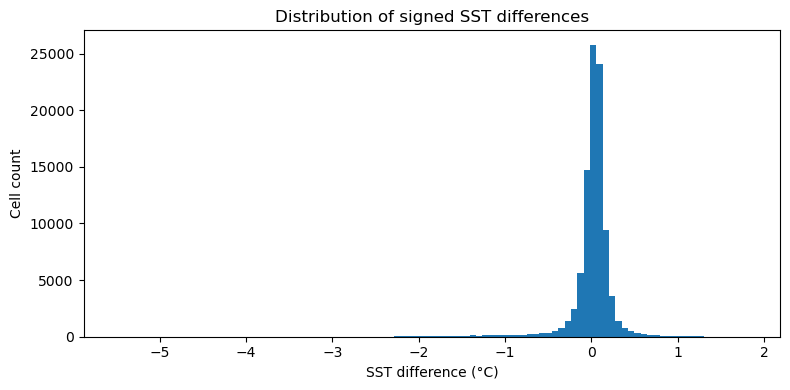

In [31]:
plt.figure(figsize=(8, 4))
plt.hist(signed_vals, bins=100)
plt.xlabel("SST difference (°C)")
plt.ylabel("Cell count")
plt.title("Distribution of signed SST differences")
plt.tight_layout()
plt.show()

### Absolute difference map

C:\Users\itsna\AppData\Local\Temp\ipykernel_25432\3146061446.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(


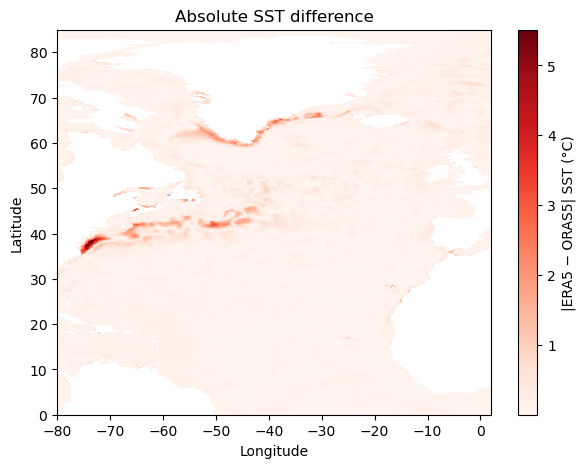

In [33]:
plt.figure(figsize=(7, 5))
plt.pcolormesh(
    abs_diff["nav_lon"],
    abs_diff["nav_lat"],
    abs_diff,
    shading="auto",
    cmap="Reds"
)
plt.colorbar(label="|ERA5 − ORAS5| SST (°C)")
plt.title("Absolute SST difference")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-80, 2)
plt.ylim(0, 85)
plt.show()

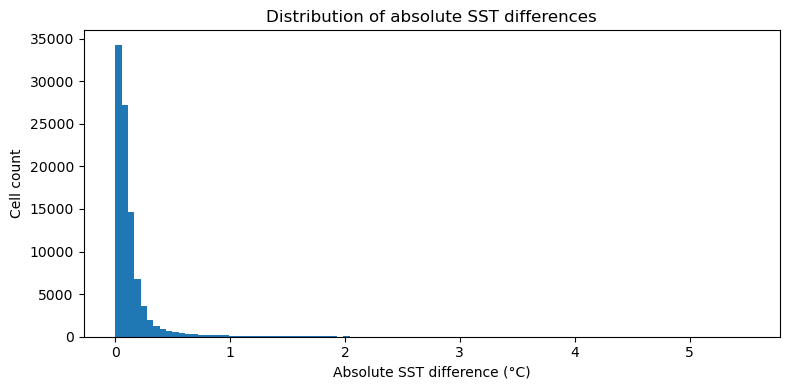

In [34]:
plt.figure(figsize=(8, 4))
plt.hist(abs_vals, bins=100)
plt.xlabel("Absolute SST difference (°C)")
plt.ylabel("Cell count")
plt.title("Distribution of absolute SST differences")
plt.tight_layout()
plt.show()

### Relative absolute difference over the UK coastal box

In [36]:
UK = dict(lon_min=-7, lon_max=-2, lat_min=49, lat_max=52)

rel_uk = rel.where(
    (rel["nav_lon"] >= UK["lon_min"]) & (rel["nav_lon"] <= UK["lon_max"]) &
    (rel["nav_lat"] >= UK["lat_min"]) & (rel["nav_lat"] <= UK["lat_max"])
)

rel_uk_vals = rel_uk.values.ravel()
rel_uk_vals = rel_uk_vals[np.isfinite(rel_uk_vals)]

print(f"UK cells compared: N = {rel_uk_vals.size}")
print(f"UK mean(rel abs diff) = {rel_uk_vals.mean():.4f}")
print(f"UK RMS(rel abs diff)  = {np.sqrt((rel_uk_vals**2).mean()):.4f}")

UK cells compared: N = 266
UK mean(rel abs diff) = 0.0060
UK RMS(rel abs diff)  = 0.0077
